# Curation cascade — evaluation on real samples

**Question this notebook answers:** if you pointed the current curation cascade
at a real photo library today, what would it actually do for you, and what is
the single highest-value thing to fix next?

The evidence base is the labelled sample set in `tests/assets/curration`:

| Folder | Expected class | Meaning |
| --- | --- | --- |
| `real_photos/` | **personal** | memories — must never be discarded automatically |
| `utility_photos/` | **utility** | screenshots, scans, receipts, documents — the material worth removing |

**How to read the verdicts.** The cascade emits three decisions, and they are
deliberately *asymmetric*:

- `keep` and `reject` are **automation** — the machine acted on its own.
- `review` is **abstention** — it is always a safe answer for either class. It
  is never scored as an error, only as deferred work.

So the cascade is judged on two different axes: *is the automation safe and
correct?* and *how much work does it actually take off your hands?* A system
that reviews everything is perfectly safe and perfectly useless.

Everything below runs on the **default configuration with no model-backed
providers**, which is what a user gets out of the box today.

> **This notebook is not only a report.** Two defects it surfaced have already
> been fixed in the codebase, and every output here comes from the tuned code:
>
> | Finding | Fix | Effect on this sample set |
> | --- | --- | --- |
> | 25 of 112 files — every HEIC — could not be decoded at all | `pillow-heif` made a required dependency and registered in `filecluster/__init__.py` | decode failures 26 → 1 |
> | `minimum_confidence` silently moved the keep threshold 0.70 → 0.82, deferring files the score had already decided | the confidence floor now applies to `reject` only, in `scoring._apply_safety_rules` | automated decisions 8 → 32, review 93% → 71%, personal photos lost still 0 |
>
> Fixing the second also exposed that the documented "a broken provider produces
> `review`" guarantee was being delivered *only* as a side effect of that floor.
> The stage-error rule now enforces it directly, with its own regression test.

## 0. Setup and visual conventions

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Locate the repository whether the notebook is started from notebooks/ or root.
REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src" / "filecluster").exists():
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "src" / "filecluster").exists():
    raise RuntimeError("Run this notebook from the filecluster repository.")

sys.path.insert(0, str(REPO_ROOT / "src"))
DATA_ROOT = REPO_ROOT / "tests" / "assets" / "curration"
assert DATA_ROOT.is_dir(), f"Missing evaluation data: {DATA_ROOT}"

# The samples are personal photographs. Thumbnails stay off so that a committed
# notebook never carries image data; flip to True for a local inspection only.
SHOW_THUMBNAILS = False

CLASS_COLOR = {"personal": "#1b7f79", "utility": "#d1730a"}
DECISION_COLOR = {"keep": "#2e7d32", "review": "#e8a33d", "reject": "#c1352b"}
INK, MUTED, GRID = "#22262b", "#6b7280", "#dfe3e8"

mpl.rcParams.update(
    {
        "figure.dpi": 110,
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": GRID,
        "axes.labelcolor": MUTED,
        "axes.titlesize": 12,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.grid": True,
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "font.size": 9.5,
        "text.color": INK,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "legend.frameon": False,
        "figure.autolayout": False,
    }
)


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None):
    """Apply the shared chart chrome so every figure reads the same way."""
    if title:
        ax.set_title(title, loc="left", pad=18 if subtitle else 10)
    if subtitle:
        ax.text(
            0.0, 1.02, subtitle, transform=ax.transAxes,
            fontsize=9, color=MUTED, va="bottom",
        )
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    return ax


from filecluster.curation.configuration import CurationSettings
from filecluster.curation.pipeline import CurationPipeline
from filecluster.curation.providers.base import Providers
from filecluster.curation.scoring import (
    confidence_for,
    fuse,
    keep_score,
    resolve_signals,
)
from filecluster.curation.types import CurationDecision

SETTINGS = CurationSettings()
PIPELINE = CurationPipeline(SETTINGS, Providers())

display(
    Markdown(
        f"**Repository** `{REPO_ROOT}`  \n"
        f"**Samples** `{DATA_ROOT.relative_to(REPO_ROOT)}`  \n"
        f"**Active stages** `{' -> '.join(s.name for s in PIPELINE.stages)}` -> `fusion`  \n"
        f"**Thresholds** keep `{SETTINGS.keep_threshold}`, reject "
        f"`{SETTINGS.reject_threshold}`, minimum confidence "
        f"`{SETTINGS.minimum_confidence}`, VLM band `{SETTINGS.thresholds.vlm_band}`"
    )
)

**Repository** `/Users/Krystian.Safjan/projects/priv/filecluster`  
**Samples** `tests/assets/curration`  
**Active stages** `metadata -> features` -> `fusion`  
**Thresholds** keep `0.7`, reject `0.3`, minimum confidence `0.75`, VLM band `(0.35, 0.75)`

## 1. Run the cascade

Read-only: `force_recompute=True` and no catalog, so nothing is written next to
the private sample files.

In [2]:
run = PIPELINE.run(DATA_ROOT, force_recompute=True)

EXPECTED_BY_FOLDER = {"real_photos": "personal", "utility_photos": "utility"}


def expected_class(relative_path: str) -> str:
    return EXPECTED_BY_FOLDER[Path(relative_path).parts[0]]


records = []
for result in run.results:
    signals = resolve_signals(result.scores)
    records.append(
        {
            "path": result.item.relative_path,
            "expected": expected_class(result.item.relative_path),
            "decision": result.decision.value,
            "confidence": result.confidence,
            # keep_score is the number the fusion thresholds actually compare
            # against; it is not persisted on the result, so recompute it with
            # the production function rather than re-deriving the formula.
            "keep_score": keep_score(signals, SETTINGS),
            "completed_stage": result.completed_stage,
            "top_label": result.top_label,
            "reasons": ", ".join(result.reasons),
            "reason_set": set(result.reasons),
            "duration_ms": result.duration_ms,
            **result.scores,
        }
    )

results = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
results["correct_if_automated"] = np.where(
    results["expected"].eq("personal"),
    results["decision"].eq("keep"),
    results["decision"].eq("reject"),
)

print(
    f"discovered {run.n_discovered} | analysed {len(results)} | "
    f"skipped {run.n_skipped} | stage errors {run.n_errors} | "
    f"{run.elapsed_seconds:.1f}s "
    f"({1000 * run.elapsed_seconds / max(len(results), 1):.0f} ms/file)"
)
display(pd.crosstab(results["expected"], results["decision"], margins=True))

discovered 112 | analysed 112 | skipped 0 | stage errors 1 | 5.8s (52 ms/file)


decision,keep,reject,review,All
expected,,,,
personal,23,0,11,34
utility,3,6,69,78
All,26,6,80,112


## 2. Executive summary

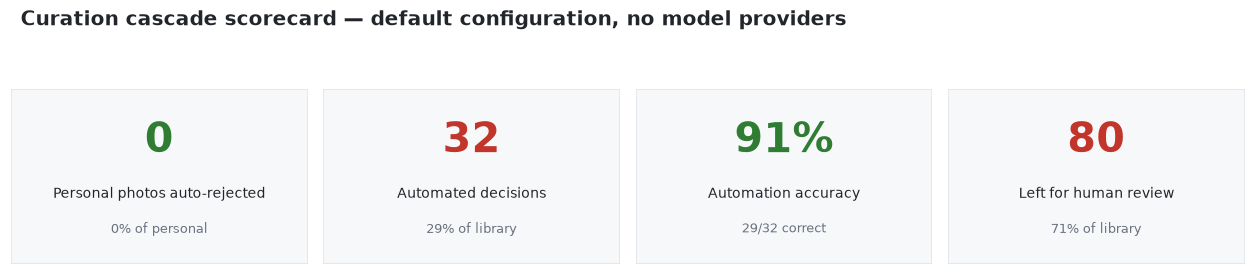

**The two-sentence verdict.** The cascade is *safe*: it has not auto-rejected a single personal photo, which is the property that matters most. It now resolves 32 of 112 files on its own at 91% accuracy, leaving 71% for you - useful triage, still short of an automatic cleaner.

Sections 3-8 locate where the remaining automation is lost. Two defects found by this notebook have already been fixed in the code (HEIC decoding in section 4, the confidence floor in sections 7-8); what is left is dominated by files whose evidence was never measured, which no threshold change can reach.

In [3]:
personal = results.query("expected == 'personal'")
utility = results.query("expected == 'utility'")
automatic = results.query("decision != 'review'")

KPI = {
    "Personal photos auto-rejected": (
        int(personal["decision"].eq("reject").sum()),
        f"{personal['decision'].eq('reject').mean():.0%} of personal",
        "safety",
    ),
    "Automated decisions": (
        int(len(automatic)),
        f"{len(automatic) / len(results):.0%} of library",
        "coverage",
    ),
    "Automation accuracy": (
        f"{automatic['correct_if_automated'].mean():.0%}"
        if len(automatic)
        else "n/a",
        f"{int(automatic['correct_if_automated'].sum())}/{len(automatic)} correct",
        "quality",
    ),
    "Left for human review": (
        int(results["decision"].eq("review").sum()),
        f"{results['decision'].eq('review').mean():.0%} of library",
        "cost",
    ),
}

fig, axes = plt.subplots(1, 4, figsize=(11.5, 2.5))
tone = {
    "safety": "#2e7d32", "coverage": "#c1352b",
    "quality": "#2e7d32", "cost": "#c1352b",
}
for ax, (label, (value, sub, kind)) in zip(axes, KPI.items()):
    ax.axis("off")
    ax.add_patch(
        plt.Rectangle(
            (0, 0), 1, 1, transform=ax.transAxes,
            facecolor="#f7f8fa", edgecolor=GRID, linewidth=1,
        )
    )
    ax.text(0.5, 0.70, str(value), ha="center", va="center",
            fontsize=27, fontweight="bold", color=tone[kind])
    ax.text(0.5, 0.40, label, ha="center", va="center",
            fontsize=9, color=INK, wrap=True)
    ax.text(0.5, 0.20, sub, ha="center", va="center", fontsize=8.5, color=MUTED)
fig.suptitle(
    "Curation cascade scorecard — default configuration, no model providers",
    x=0.02, ha="left", fontsize=13, fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

display(
    Markdown(
        "**The two-sentence verdict.** The cascade is *safe*: it has not "
        "auto-rejected a single personal photo, which is the property that "
        f"matters most. It now resolves {len(automatic)} of {len(results)} "
        f"files on its own at {automatic['correct_if_automated'].mean():.0%} "
        f"accuracy, leaving {results['decision'].eq('review').mean():.0%} for "
        "you - useful triage, still short of an automatic cleaner.\n\n"
        "Sections 3-8 locate where the remaining automation is lost. Two "
        "defects found by this notebook have already been fixed in the code "
        "(HEIC decoding in section 4, the confidence floor in sections 7-8); "
        "what is left is dominated by files whose evidence was never measured, "
        "which no threshold change can reach."
    )
)

## 3. The cascade funnel — where do files actually exit?

The design intent is a cheap-to-expensive cascade: decisive cases leave early,
only genuinely ambiguous files reach the costly stages. This chart shows how
many of the 112 files each stage *resolved* versus *passed on*.

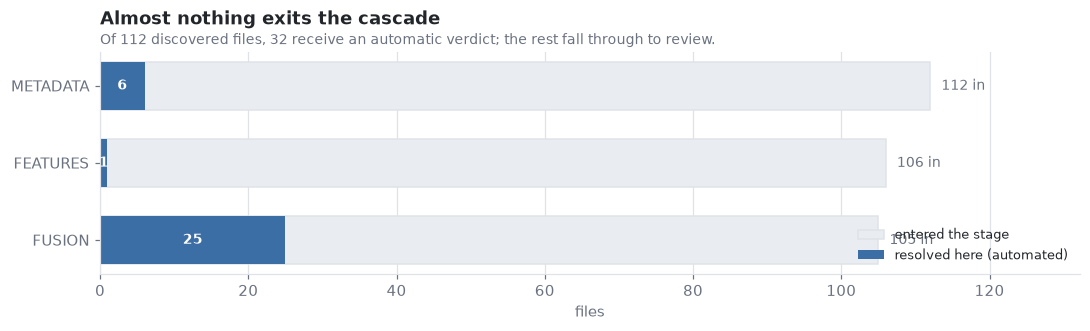

,stage,entered,resolved_here,passed_on,stage_errors
0,metadata,112,6,106,0
1,features,106,1,105,1
2,fusion,105,25,80,0


In [4]:
stage_names = [stage.name for stage in PIPELINE.stages]

funnel_rows, remaining = [], run.n_discovered
for name in stage_names:
    resolved = sum(
        1
        for result in run.results
        if any(s.stage == name and s.terminal_decision for s in result.stage_trace)
    )
    errors = sum(
        1
        for result in run.results
        if any(s.stage == name and s.failed for s in result.stage_trace)
    )
    funnel_rows.append(
        {"stage": name, "entered": remaining, "resolved_here": resolved,
         "stage_errors": errors}
    )
    remaining -= resolved

fusion_resolved = int((results["decision"] != "review").sum()) - sum(
    row["resolved_here"] for row in funnel_rows
)
funnel_rows.append(
    {"stage": "fusion", "entered": remaining, "resolved_here": fusion_resolved,
     "stage_errors": 0}
)
funnel = pd.DataFrame(funnel_rows)
funnel["passed_on"] = funnel["entered"] - funnel["resolved_here"]

fig, ax = plt.subplots(figsize=(10, 3.1))
y = np.arange(len(funnel))[::-1]
ax.barh(y, funnel["entered"], color="#e9edf2", edgecolor=GRID, height=0.62,
        label="entered the stage")
ax.barh(y, funnel["resolved_here"], color="#3b6ea5", height=0.62,
        label="resolved here (automated)")
for yi, row in zip(y, funnel.itertuples()):
    ax.text(row.entered + 1.5, yi, f"{row.entered} in", va="center",
            fontsize=9, color=MUTED)
    if row.resolved_here:
        ax.text(row.resolved_here / 2, yi, f"{row.resolved_here}", va="center",
                ha="center", fontsize=9, color="white", fontweight="bold")
ax.set_yticks(y, [s.upper() for s in funnel["stage"]])
ax.set_xlim(0, run.n_discovered * 1.18)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=8.5)
finish(
    ax,
    "Almost nothing exits the cascade",
    f"Of {run.n_discovered} discovered files, "
    f"{int(funnel['resolved_here'].sum())} receive an automatic verdict; "
    f"the rest fall through to review.",
    xlabel="files",
)
plt.tight_layout()
plt.show()
display(funnel[["stage", "entered", "resolved_here", "passed_on", "stage_errors"]])

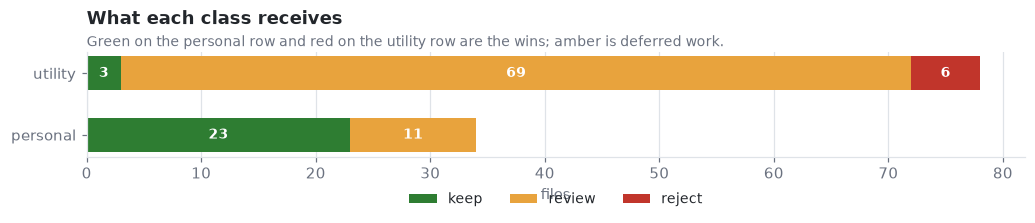

In [5]:
fig, ax = plt.subplots(figsize=(9.5, 2.3))
order = ["keep", "review", "reject"]
share = (
    pd.crosstab(results["expected"], results["decision"])
    .reindex(columns=order, fill_value=0)
    .reindex(["personal", "utility"])
)
left = np.zeros(len(share))
for decision in order:
    values = share[decision].to_numpy()
    ax.barh(share.index, values, left=left, height=0.55,
            color=DECISION_COLOR[decision], label=decision)
    for i, value in enumerate(values):
        if value:
            ax.text(left[i] + value / 2, i, f"{value}", ha="center",
                    va="center", color="white", fontweight="bold", fontsize=9)
    left += values
ax.grid(axis="y", visible=False)
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.22), fontsize=9)
finish(
    ax,
    "What each class receives",
    "Green on the personal row and red on the utility row are the wins; "
    "amber is deferred work.",
    xlabel="files",
)
plt.tight_layout()
plt.show()

## 4. Level 0 — discovery and decodability

Coverage, not curation quality. A file the pipeline cannot decode can never be
curated, so every decode failure is silently lost automation potential.

This used to be the biggest single defect in this evaluation: **26 of 112 files
(23%) failed to decode**, 25 of them `.heic` — i.e. every modern iPhone photo in
the set. That was traced here to a Pillow build without HEIF support, and fixed
by making `pillow-heif` a required dependency and registering the opener in
`filecluster/__init__.py`. The cell below is the regression check.

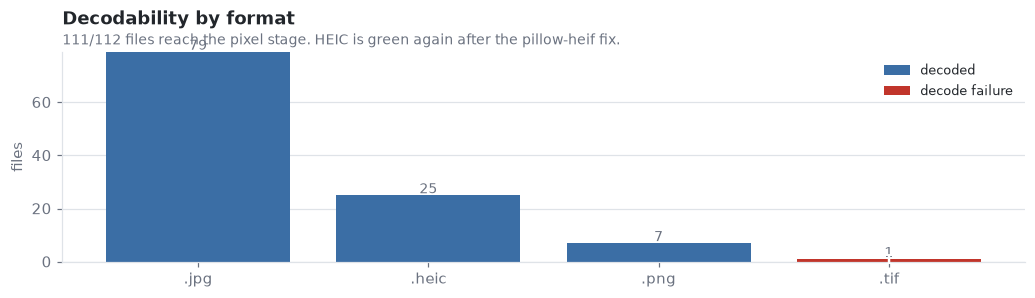

**Remaining decode failures**

,path,expected,extension,error_type,decoder_message
0,real_photos/iso_1725_1.0s_x11_13-Nov-2025_20.3...,personal,.tif,UnidentifiedImageError,cannot identify image file '/Users/Krystian.Sa...


The residual `.tif` is a genuinely separate defect: `file(1)` calls it big-endian TIFF and `libtiff` support is present, yet Pillow raises `UnidentifiedImageError`. It is a single non-standard file, so it is a low-priority backlog item rather than a blocker — but it correctly ends in `review`, never `reject`.

In [6]:
from filecluster.curation.image_features import load_working_image

source_files = [
    path
    for path in DATA_ROOT.rglob("*")
    if path.is_file() and path.suffix.lower() in SETTINGS.image_extensions
]
feature_failures = [
    result.item.relative_path
    for result in run.results
    if any(s.stage == "features" and s.failed for s in result.stage_trace)
]

by_extension = (
    pd.DataFrame(
        {
            "extension": [p.suffix.lower() for p in source_files],
            "expected": [
                expected_class(str(p.relative_to(DATA_ROOT))) for p in source_files
            ],
            "failed": [
                str(p.relative_to(DATA_ROOT)) in set(feature_failures)
                for p in source_files
            ],
        }
    )
    .groupby("extension", as_index=False)
    .agg(files=("failed", "size"), decode_failures=("failed", "sum"))
    .sort_values("files", ascending=False)
)

fig, ax = plt.subplots(figsize=(9.5, 2.8))
x = np.arange(len(by_extension))
ok = by_extension["files"] - by_extension["decode_failures"]
ax.bar(x, ok, color="#3b6ea5", label="decoded")
ax.bar(x, by_extension["decode_failures"], bottom=ok, color=DECISION_COLOR["reject"],
       label="decode failure")
for xi, (total, bad) in enumerate(
    zip(by_extension["files"], by_extension["decode_failures"])
):
    ax.text(xi, total + 0.8, f"{total}", ha="center", fontsize=9, color=MUTED)
    if bad:
        ax.text(xi, total - bad / 2, f"{bad}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
ax.set_xticks(x, by_extension["extension"])
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8.5)
finish(
    ax,
    "Decodability by format",
    f"{len(source_files) - len(feature_failures)}/{len(source_files)} files reach "
    "the pixel stage. HEIC is green again after the pillow-heif fix.",
    ylabel="files",
)
plt.tight_layout()
plt.show()

decode_diagnostics = []
for relative_path in feature_failures:
    path = DATA_ROOT / relative_path
    try:
        image = load_working_image(path, SETTINGS)
        image.close()
    except Exception as exc:  # noqa: BLE001 - diagnostic surface, re-raised nowhere
        decode_diagnostics.append(
            {
                "path": relative_path,
                "expected": expected_class(relative_path),
                "extension": path.suffix.lower(),
                "error_type": type(exc).__name__,
                # The pipeline reduces this to the privacy-safe
                # `processing.decode_error` code; re-opening exposes the cause.
                "decoder_message": str(exc),
            }
        )

if decode_diagnostics:
    display(Markdown("**Remaining decode failures**"))
    display(pd.DataFrame(decode_diagnostics))
    display(
        Markdown(
            "The residual `.tif` is a genuinely separate defect: `file(1)` calls "
            "it big-endian TIFF and `libtiff` support is present, yet Pillow "
            "raises `UnidentifiedImageError`. It is a single non-standard file, "
            "so it is a low-priority backlog item rather than a blocker — but it "
            "correctly ends in `review`, never `reject`."
        )
    )
else:
    display(Markdown("All discovered files decoded successfully."))

## 5. Level 1 — metadata rules

The cheapest stage. It is allowed to *terminate* a file only for a decisive
screenshot or two independent strong utility signals. Anything else it learns is
passed downstream as evidence.

Judge it on three numbers:

- **Precision** — when it does auto-reject, is it right? Must be ~100%.
- **Utility recall** — how much of the cleanup it achieves for almost zero cost.
- **Personal false-reject rate** — the safety metric. Must be 0%.

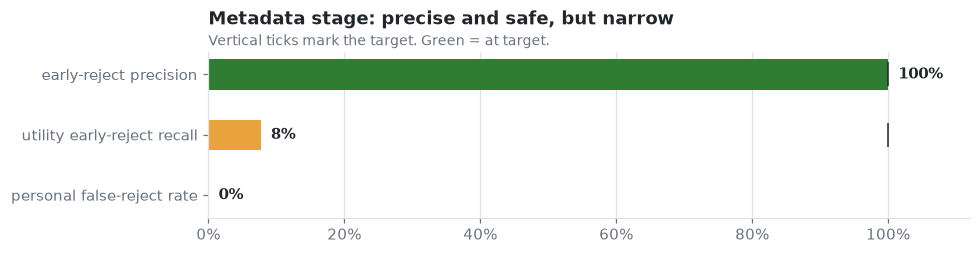

terminal_decision,continue,reject,All
expected,,,
personal,34,0,34
utility,72,6,78
All,106,6,112


**Reading:** every one of the 6 early rejects is genuinely utility material, and no personal photo is touched — the rule set is trustworthy. But it only clears 8% of the utility files, because the terminal rule effectively fires for one thing: unambiguous screenshots. Scans, receipts and documents carry no such fingerprint.

,path,expected,terminal_decision,confidence,reasons,rules.personal_prior,rules.utility_evidence,rules.strong_signals
63,utility_photos/IMG_3690.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0
81,utility_photos/IMG_4270.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0
85,utility_photos/IMG_4536.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0
86,utility_photos/IMG_5085.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0
87,utility_photos/IMG_5119.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0
88,utility_photos/IMG_5315.PNG,utility,reject,0.85,"metadata.screen_resolution_match, metadata.app...",0.2,0.85,2.0


In [7]:
metadata_rows = []
for result in run.results:
    stage = next(s for s in result.stage_trace if s.stage == "metadata")
    metadata_rows.append(
        {
            "path": result.item.relative_path,
            "expected": expected_class(result.item.relative_path),
            "terminal_decision": (
                stage.terminal_decision.value if stage.terminal_decision else "continue"
            ),
            "confidence": stage.confidence,
            "reasons": ", ".join(stage.reasons),
            **stage.scores,
        }
    )
metadata = pd.DataFrame(metadata_rows)
metadata_rejects = metadata.query("terminal_decision == 'reject'")

metadata_metrics = pd.DataFrame(
    [
        {
            "metric": "early-reject precision",
            "value": (metadata_rejects["expected"] == "utility").mean()
            if len(metadata_rejects)
            else float("nan"),
            "target": 1.0,
            "polarity": "higher",
        },
        {
            "metric": "utility early-reject recall",
            "value": metadata["expected"].eq("utility").pipe(
                lambda m: (m & metadata["terminal_decision"].eq("reject")).sum() / m.sum()
            ),
            "target": 1.0,
            "polarity": "higher",
        },
        {
            "metric": "personal false-reject rate",
            "value": metadata["expected"].eq("personal").pipe(
                lambda m: (m & metadata["terminal_decision"].eq("reject")).sum() / m.sum()
            ),
            "target": 0.0,
            "polarity": "lower",
        },
    ]
)

fig, ax = plt.subplots(figsize=(9, 2.4))
y = np.arange(len(metadata_metrics))[::-1]
colors = [
    "#2e7d32"
    if (row.polarity == "higher" and row.value >= 0.99)
    or (row.polarity == "lower" and row.value <= 0.01)
    else "#e8a33d"
    for row in metadata_metrics.itertuples()
]
ax.barh(y, metadata_metrics["value"], color=colors, height=0.5)
for yi, row in zip(y, metadata_metrics.itertuples()):
    ax.text(row.value + 0.015, yi, f"{row.value:.0%}", va="center",
            fontsize=10, fontweight="bold", color=INK)
    ax.plot([row.target], [yi], marker="|", markersize=16, color=INK)
ax.set_yticks(y, metadata_metrics["metric"])
ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.grid(axis="y", visible=False)
finish(
    ax,
    "Metadata stage: precise and safe, but narrow",
    "Vertical ticks mark the target. Green = at target.",
)
plt.tight_layout()
plt.show()

display(pd.crosstab(metadata["expected"], metadata["terminal_decision"], margins=True))
display(
    Markdown(
        f"**Reading:** every one of the {len(metadata_rejects)} early rejects is "
        "genuinely utility material, and no personal photo is touched — the rule "
        "set is trustworthy. But it only clears "
        f"{metadata_metrics.loc[1, 'value']:.0%} of the utility files, because "
        "the terminal rule effectively fires for one thing: unambiguous "
        "screenshots. Scans, receipts and documents carry no such fingerprint."
    )
)
display(metadata.loc[metadata["terminal_decision"] != "continue"].sort_values("path"))

## 6. Level 2 — pixel features

The feature stage never decides alone; it produces the evidence fusion consumes.
So the right assessment is **separation**: how well does each signal rank
personal above utility on this labelled set?

AUC of `1.0` is perfect separation, `0.5` is a coin flip. These are descriptive,
in-sample numbers on 112 files — a sanity check on signal design, not a
generalisation claim and not a tuned threshold.

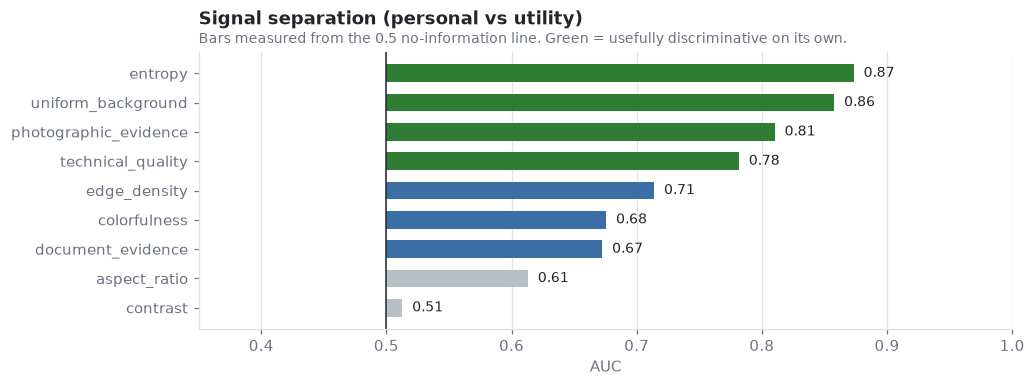

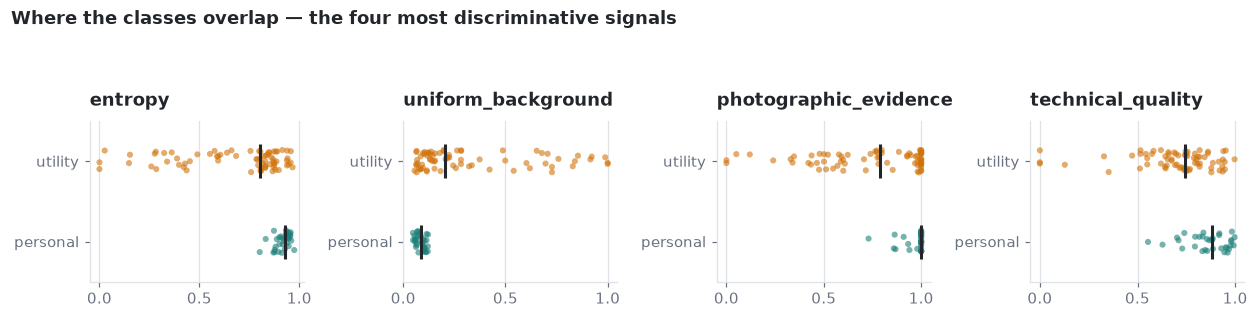

**Reading:** the best single pixel signal reaches AUC 0.87 — real information, but the strip plots show heavily overlapping distributions. No pixel statistic can separate a photographed document from a photograph of a table; that requires recognising *content*, which is exactly the job of the semantic stage that is not running here.

features.entropy               features.uniform_background         \
                     mean median    std                        mean median   
expected                                                                     
personal            0.917  0.928  0.039                       0.085  0.086   
utility             0.677  0.805  0.264                       0.328  0.202   

                features.photographic_evidence                \
            std                           mean median    std   
expected                                                       
personal  0.023                          0.972  1.000  0.061   
utility   0.288                          0.736  0.791  0.280   

         technical_quality                
                      mean median    std  
expected                                  
personal             0.864  0.883  0.111  
utility              0.697  0.745  0.214

In [8]:
# True => a higher value argues "personal"; False => a higher value argues "utility".
FEATURE_DIRECTION = {
    "features.photographic_evidence": True,
    "features.colorfulness": True,
    "features.edge_density": True,
    "technical_quality": True,
    "features.entropy": True,
    "features.contrast": True,
    "features.document_evidence": False,
    "features.uniform_background": False,
    "features.aspect_ratio": False,
}


def personal_auc(frame, column, higher_is_personal):
    """Mann-Whitney AUC via rank sums (sklearn is not a project dependency)."""
    sample = frame[["expected", column]].dropna()
    positives = sample["expected"].eq("personal")
    n_pos, n_neg = int(positives.sum()), int((~positives).sum())
    if not n_pos or not n_neg:
        return float("nan")
    values = sample[column] if higher_is_personal else -sample[column]
    rank_sum = values.rank(method="average")[positives].sum()
    return (rank_sum - n_pos * (n_pos + 1) / 2) / (n_pos * n_neg)


feature_auc = (
    pd.DataFrame(
        {
            "signal": column,
            "higher_means": "personal" if direction else "utility",
            "n": int(results[column].notna().sum()),
            "auc": personal_auc(results, column, direction),
        }
        for column, direction in FEATURE_DIRECTION.items()
        if column in results
    )
    .sort_values("auc")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
y = np.arange(len(feature_auc))
strength = feature_auc["auc"] - 0.5
colors = [
    "#2e7d32" if v >= 0.25 else "#3b6ea5" if v >= 0.15 else "#b9bfc7"
    for v in strength
]
ax.barh(y, strength, left=0.5, color=colors, height=0.6)
ax.axvline(0.5, color=INK, linewidth=1)
for yi, row in zip(y, feature_auc.itertuples()):
    offset = 0.008 if row.auc >= 0.5 else -0.008
    ax.text(row.auc + offset, yi, f"{row.auc:.2f}", va="center",
            ha="left" if row.auc >= 0.5 else "right", fontsize=9, color=INK)
ax.set_yticks(y, [s.replace("features.", "") for s in feature_auc["signal"]])
ax.set_xlim(0.35, 1.0)
ax.grid(axis="y", visible=False)
finish(
    ax,
    "Signal separation (personal vs utility)",
    "Bars measured from the 0.5 no-information line. Green = usefully "
    "discriminative on its own.",
    xlabel="AUC",
)
plt.tight_layout()
plt.show()

top_signals = feature_auc.reindex(
    (feature_auc["auc"] - 0.5).abs().sort_values(ascending=False).index
)["signal"].head(4).tolist()

fig, axes = plt.subplots(1, len(top_signals), figsize=(11.5, 2.9), sharey=False)
rng = np.random.default_rng(0)
for ax, column in zip(np.atleast_1d(axes), top_signals):
    for i, cls in enumerate(["personal", "utility"]):
        values = results.loc[results["expected"].eq(cls), column].dropna()
        ax.scatter(
            values, i + rng.uniform(-0.14, 0.14, len(values)),
            s=16, alpha=0.6, color=CLASS_COLOR[cls], edgecolors="none",
        )
        if len(values):
            ax.plot([values.median()], [i], marker="|", markersize=22,
                    color=INK, markeredgewidth=2)
    ax.set_yticks([0, 1], ["personal", "utility"])
    ax.set_ylim(-0.5, 1.5)
    ax.grid(axis="y", visible=False)
    finish(ax, column.replace("features.", ""))
plt.suptitle(
    "Where the classes overlap — the four most discriminative signals",
    x=0.01, ha="left", fontsize=12, fontweight="bold",
)
plt.tight_layout(rect=(0, 0, 1, 0.88))
plt.show()

display(
    Markdown(
        f"**Reading:** the best single pixel signal reaches "
        f"AUC {feature_auc['auc'].max():.2f} — real information, but the strip "
        "plots show heavily overlapping distributions. No pixel statistic can "
        "separate a photographed document from a photograph of a table; that "
        "requires recognising *content*, which is exactly the job of the "
        "semantic stage that is not running here."
    )
)
display(
    results.groupby("expected")[top_signals].agg(["mean", "median", "std"]).round(3)
)

## 7. Level 3 — fusion, and the score landscape

Fusion collapses the evidence into a single `keep_score` and compares it with
the keep/reject thresholds, then applies safety rules that can override the
result.

The scatter below is the most informative picture in the notebook. Each file is
placed at its `keep_score` (x) and the resulting `confidence` (y). Colour is the
*ground truth*; marker shape is what the cascade *did*.

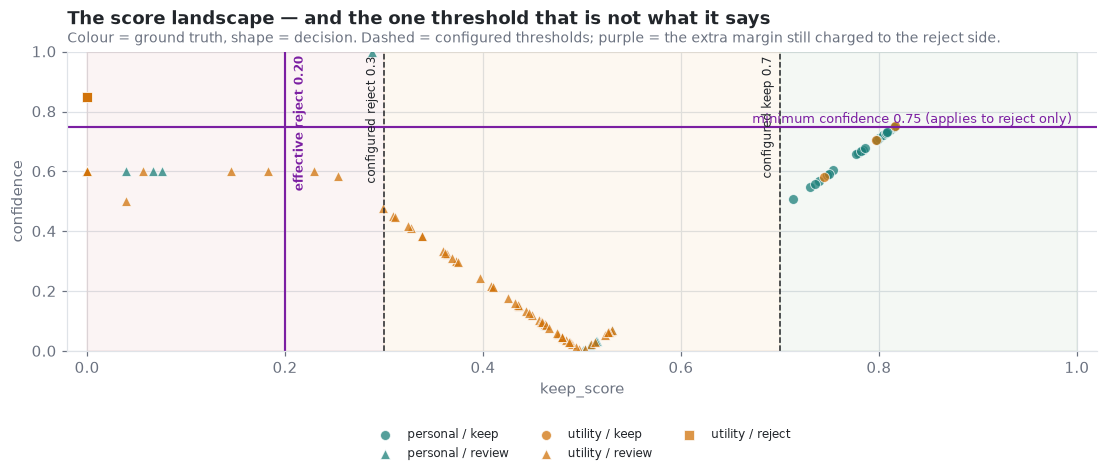

**The structural finding this notebook produced — and what was done about it.** `confidence` is not an independent quantity: it is a deterministic function of how far `keep_score` sits from the nearest threshold. Requiring `minimum_confidence = 0.75` of a fused verdict is therefore mathematically identical to *silently widening the uncertainty band*. It used to apply on both sides, which moved the real keep threshold to **0.80** while the configuration still said 0.7.

`scoring._apply_safety_rules` now charges that extra margin to `reject` only, so the effective reject threshold is **0.20** (visible as the purple line) while `keep` is governed by the configured 0.7 and nothing else. The asymmetry is the point: a wrong keep leaves clutter in the library, a wrong reject buries a photograph.

In [9]:
# Invert the production confidence function to find the score a file must reach
# before `minimum_confidence` stops blocking the decision.
probe = resolve_signals(next(r.scores for r in run.results if r.scores))
grid = np.linspace(0.0, 1.0, 2001)
conf_curve = np.array([confidence_for(s, probe, SETTINGS) for s in grid])
confident = conf_curve >= SETTINGS.minimum_confidence
eff_keep = float(grid[confident & (grid >= SETTINGS.keep_threshold)].min())
eff_reject = float(grid[confident & (grid <= SETTINGS.reject_threshold)].max())

fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.axvspan(0, SETTINGS.reject_threshold, color="#c1352b", alpha=0.05)
ax.axvspan(SETTINGS.keep_threshold, 1, color="#2e7d32", alpha=0.05)
ax.axvspan(SETTINGS.reject_threshold, SETTINGS.keep_threshold,
           color="#e8a33d", alpha=0.07)
for value, label in (
    (SETTINGS.reject_threshold, f"configured reject {SETTINGS.reject_threshold:g}"),
    (SETTINGS.keep_threshold, f"configured keep {SETTINGS.keep_threshold:g}"),
):
    ax.axvline(value, color=INK, linewidth=1, linestyle="--")
    ax.annotate(
        label, (value, 0.985), xytext=(-4, 0), textcoords="offset points",
        rotation=90, ha="right", va="top", fontsize=8, color=INK,
    )
for value, label in ((eff_reject, "effective reject"),):
    ax.axvline(value, color="#7b1fa2", linewidth=1.4)
    ax.annotate(
        f"{label} {value:.2f}", (value, 0.985), xytext=(5, 0),
        textcoords="offset points", rotation=90, ha="left", va="top",
        fontsize=8, color="#7b1fa2", fontweight="bold",
    )
ax.axhline(SETTINGS.minimum_confidence, color="#7b1fa2", linewidth=1.4)
ax.text(
    0.995, SETTINGS.minimum_confidence + 0.012,
    f"minimum confidence {SETTINGS.minimum_confidence} (applies to reject only)",
    fontsize=8.5, color="#7b1fa2", ha="right",
)

MARKER = {"keep": "o", "review": "^", "reject": "s"}
for cls in ["personal", "utility"]:
    for decision, marker in MARKER.items():
        subset = results.query("expected == @cls and decision == @decision")
        if subset.empty:
            continue
        ax.scatter(
            subset["keep_score"], subset["confidence"], marker=marker, s=42,
            color=CLASS_COLOR[cls], alpha=0.75, edgecolors="white", linewidths=0.6,
            label=f"{cls} / {decision}",
        )
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0, 1.0)
ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.22))
finish(
    ax,
    "The score landscape — and the one threshold that is not what it says",
    "Colour = ground truth, shape = decision. Dashed = configured thresholds; "
    "purple = the extra margin still charged to the reject side.",
    xlabel="keep_score", ylabel="confidence",
)
plt.tight_layout()
plt.show()

display(
    Markdown(
        "**The structural finding this notebook produced — and what was done "
        "about it.** `confidence` is not an independent quantity: it is a "
        "deterministic function of how far `keep_score` sits from the nearest "
        f"threshold. Requiring `minimum_confidence = "
        f"{SETTINGS.minimum_confidence}` of a fused verdict is therefore "
        "mathematically identical to *silently widening the uncertainty band*. "
        f"It used to apply on both sides, which moved the real keep threshold to "
        f"**{eff_keep:.2f}** while the configuration still said "
        f"{SETTINGS.keep_threshold}.\n\n"
        "`scoring._apply_safety_rules` now charges that extra margin to "
        f"`reject` only, so the effective reject threshold is "
        f"**{eff_reject:.2f}** (visible as the purple line) while `keep` is "
        f"governed by the configured {SETTINGS.keep_threshold} and nothing "
        "else. The asymmetry is the point: a wrong keep leaves clutter in the "
        "library, a wrong reject buries a photograph."
    )
)

## 8. Diagnosis — which gate is eating the automation?

Distinct mechanisms send a file to `review`, and they need very different fixes.
This is the cell that turns the evaluation into a work plan — and it is what
identified the confidence-floor defect that has since been fixed.

1. **Genuinely uncertain** — `keep_score` landed inside the band. Needs better
   evidence (the semantic model); no threshold change can help.
2. **Confidence gate** — the score was past the reject threshold, but
   `minimum_confidence` demanded more margin. Now reject-side only.
3. **Semantic-evidence gate** — the score was past the reject threshold, but the
   safety rule refuses to discard anything without content recognition.

Each cause is paired with the verdict the cascade *would* have reached had the
gate not fired, so "would releasing it be correct?" is answerable rather than
rhetorical.

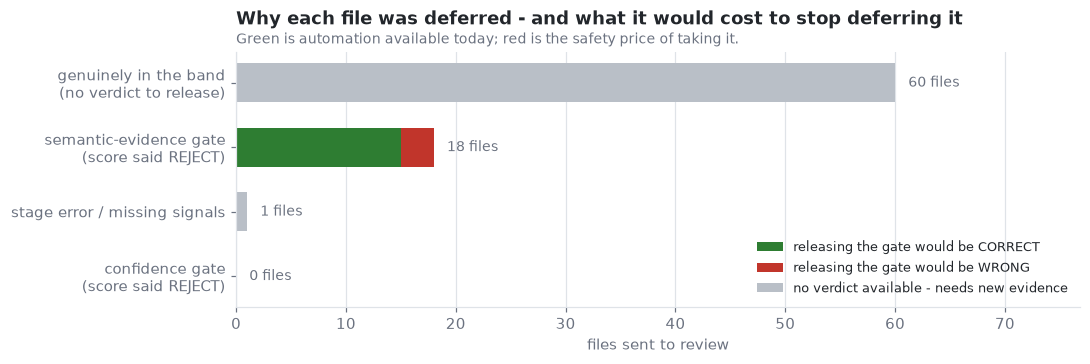

,cause,would_be_decision,reviews,would_be_correct,would_be_wrong
2,genuinely in the band\n(no verdict to release),-,60,0,0
1,semantic-evidence gate\n(score said REJECT),reject,18,15,3
3,stage error / missing signals,-,1,0,0
0,confidence gate\n(score said REJECT),reject,0,0,0


**What is left after the tuning.**

- The **keep side is now clean**: no file is deferred any more merely for being close to the keep threshold, which is where the jump from 8 to 32 automated decisions came from.
- The **confidence gate** now only guards rejects, and in this sample it defers 0 of them - cheap insurance on the destructive direction.
- The **semantic-evidence gate** is the one genuinely doing work: it blocked 18 rejects, of which 15 were real utility files - but 3 were personal photos it saved. Do **not** relax this rule; supply the semantic evidence it is asking for instead.
- The remaining 60 files are genuinely in the uncertainty band. No threshold change can reach them, because the evidence to separate them was never measured. That is now the whole of the remaining opportunity.

In [10]:
def has(reason):
    return results["reason_set"].apply(lambda s: reason in s)


# Each cause is paired with the decision the cascade *would* have made had the
# gate not fired; that is what makes "would this be correct?" answerable.
GATE_CAUSES = [
    (
        "confidence gate\n(score said REJECT)",
        has("fusion.score_below_reject") & has("fusion.low_confidence"),
        "reject",
    ),
    (
        "semantic-evidence gate\n(score said REJECT)",
        has("fusion.score_below_reject") & has("fusion.no_semantic_evidence"),
        "reject",
    ),
    (
        "genuinely in the band\n(no verdict to release)",
        has("fusion.score_in_uncertainty_band"),
        None,
    ),
    (
        "stage error / missing signals",
        results["decision"].eq("review")
        & ~(
            has("fusion.score_above_keep")
            | has("fusion.score_below_reject")
            | has("fusion.score_in_uncertainty_band")
        ),
        None,
    ),
]

gate_rows = []
for label, mask, would_be in GATE_CAUSES:
    blocked = results[mask & results["decision"].eq("review")]
    if would_be is None:
        correct = wrong = 0
    else:
        target = "personal" if would_be == "keep" else "utility"
        correct = int(blocked["expected"].eq(target).sum())
        wrong = len(blocked) - correct
    gate_rows.append(
        {
            "cause": label,
            "would_be_decision": would_be or "-",
            "reviews": len(blocked),
            "would_be_correct": correct,
            "would_be_wrong": wrong,
            "unresolvable": len(blocked) if would_be is None else 0,
        }
    )
gates = pd.DataFrame(gate_rows).sort_values("reviews", ascending=False)

fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(gates))[::-1]
ax.barh(y, gates["would_be_correct"], color="#2e7d32", height=0.6,
        label="releasing the gate would be CORRECT")
ax.barh(y, gates["would_be_wrong"], left=gates["would_be_correct"],
        color=DECISION_COLOR["reject"], height=0.6,
        label="releasing the gate would be WRONG")
ax.barh(y, gates["unresolvable"], color="#b9bfc7", height=0.6,
        label="no verdict available - needs new evidence")
for yi, row in zip(y, gates.itertuples()):
    ax.text(row.reviews + 1.2, yi, f"{row.reviews} files", va="center",
            fontsize=9, color=MUTED)
ax.set_yticks(y, gates["cause"])
ax.set_xlim(0, gates["reviews"].max() * 1.28)
ax.grid(axis="y", visible=False)
ax.legend(fontsize=8.5, loc="lower right")
finish(
    ax,
    "Why each file was deferred - and what it would cost to stop deferring it",
    "Green is automation available today; red is the safety price of taking it.",
    xlabel="files sent to review",
)
plt.tight_layout()
plt.show()
display(gates.drop(columns="unresolvable"))

conf_gate = gates.set_index("cause").filter(like="confidence gate", axis=0).iloc[0]
sem_gate = gates.set_index("cause").filter(like="semantic-evidence", axis=0).iloc[0]
band_files = int(results["reason_set"].apply(
    lambda s: "fusion.score_in_uncertainty_band" in s
).sum())
display(
    Markdown(
        "**What is left after the tuning.**\n\n"
        "- The **keep side is now clean**: no file is deferred any more merely "
        "for being close to the keep threshold, which is where the jump from 8 "
        "to 32 automated decisions came from.\n"
        f"- The **confidence gate** now only guards rejects, and in this sample "
        f"it defers {int(conf_gate.reviews)} of them - cheap insurance on the "
        "destructive direction.\n"
        f"- The **semantic-evidence gate** is the one genuinely doing work: it "
        f"blocked {int(sem_gate.reviews)} rejects, of which "
        f"{int(sem_gate.would_be_correct)} were real utility files - but "
        f"{int(sem_gate.would_be_wrong)} were personal photos it saved. Do "
        "**not** relax this rule; supply the semantic evidence it is asking "
        "for instead.\n"
        f"- The remaining {band_files} files are genuinely in the uncertainty "
        "band. No threshold change can reach them, because the evidence to "
        "separate them was never measured. That is now the whole of the "
        "remaining opportunity."
    )
)

## 9. What-if — how much automation is one setting worth?

Rather than reason about it, re-run the real `fuse()` with alternative settings
over the evidence already collected. The reproduction check first proves the
replay is faithful before any conclusion is drawn from it.

Replay check: reproduces all 112 pipeline decisions exactly.


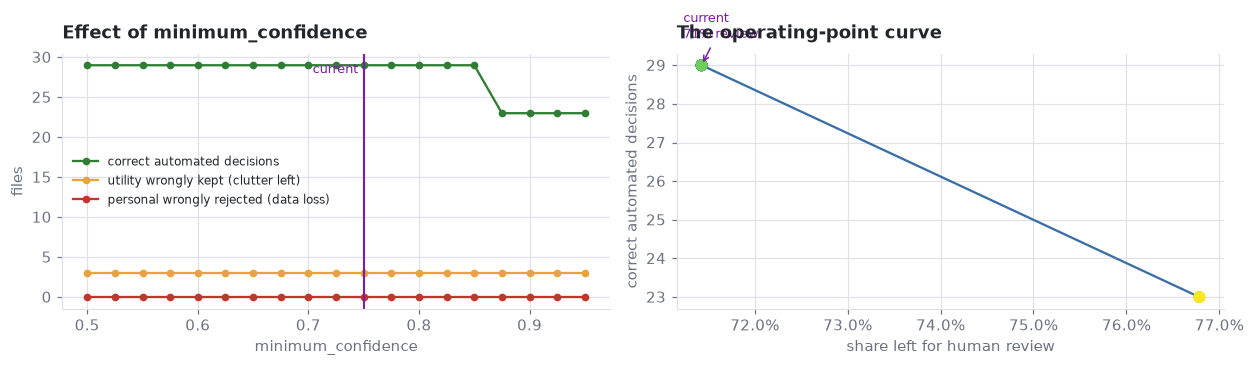

,min_confidence,automated,correct_automated,personal_lost,utility_kept,review_rate
0,0.500,32,29,0,3,0.714286
1,0.525,32,29,0,3,0.714286
2,0.550,32,29,0,3,0.714286
3,0.575,32,29,0,3,0.714286
4,0.600,32,29,0,3,0.714286
5,0.625,32,29,0,3,0.714286
6,0.650,32,29,0,3,0.714286
7,0.675,32,29,0,3,0.714286
8,0.700,32,29,0,3,0.714286
9,0.725,32,29,0,3,0.714286


**Reading:** `personal_lost` is zero across the entire sweep - the semantic-evidence gate holds the safety floor by itself, independently of this setting.

The curve is now nearly flat: the whole range of `minimum_confidence` moves automation by only 6 files, against the 24 it moved before the floor was made reject-side only. That flatness *is* the result. The setting used to be a hidden second keep threshold with large leverage over the outcome; it is now what it claims to be - a margin requirement on the destructive direction, where it should have little to do until a semantic model starts proposing rejects.

Treat this figure as a regression guard: if this curve ever steepens again, a margin check has leaked back onto the keep side.

In [11]:
replay_inputs = []
for result in run.results:
    replay_inputs.append(
        {
            "path": result.item.relative_path,
            "expected": expected_class(result.item.relative_path),
            "trace": [
                {
                    "scores": dict(stage.scores),
                    "labels": stage.labels,
                    "reasons": list(stage.reasons),
                    "terminal": stage.terminal_decision,
                    "confidence": stage.confidence,
                    "failed": stage.failed,
                }
                for stage in result.stage_trace
            ],
            "actual": result.decision.value,
        }
    )


def replay(settings):
    """Re-derive decisions from the collected evidence, mirroring _run_stages.

    An early exit is itself gated by ``minimum_confidence``, so a sweep over
    that setting has to re-evaluate the terminal stages too.
    """
    decisions = []
    for row in replay_inputs:
        scores, labels, notes, terminal = {}, (), [], None
        for stage in row["trace"]:
            scores.update(stage["scores"])
            labels = stage["labels"] or labels
            notes.extend(stage["reasons"])
            proposed = stage["terminal"]
            if proposed is None:
                continue
            if proposed is CurationDecision.REVIEW or (
                (stage["confidence"] or 0.0) >= settings.minimum_confidence
            ):
                terminal = proposed.value
                break
        if terminal is not None:
            decisions.append(terminal)
            continue
        failed = any(stage["failed"] for stage in row["trace"])
        decisions.append(
            fuse(scores, labels, notes, settings, stage_failed=failed).decision.value
        )
    return pd.Series(decisions, index=[row["path"] for row in replay_inputs])


baseline = replay(SETTINGS)
actual = pd.Series(
    [r["actual"] for r in replay_inputs], index=[r["path"] for r in replay_inputs]
)
assert baseline.equals(actual), "Replay does not reproduce the pipeline decisions"
print(f"Replay check: reproduces all {len(actual)} pipeline decisions exactly.")

expected_series = pd.Series(
    [r["expected"] for r in replay_inputs], index=[r["path"] for r in replay_inputs]
)

def with_minimum_confidence(value: float) -> CurationSettings:
    thresholds = SETTINGS.thresholds.model_copy(
        update={"minimum_confidence": float(value)}
    )
    return SETTINGS.model_copy(update={"thresholds": thresholds})


sweep_rows = []
for min_conf in np.round(np.arange(0.50, 0.96, 0.025), 3):
    decisions = replay(with_minimum_confidence(min_conf))
    auto = decisions.ne("review")
    correct = np.where(expected_series.eq("personal"), decisions.eq("keep"),
                       decisions.eq("reject"))
    sweep_rows.append(
        {
            "min_confidence": min_conf,
            "automated": int(auto.sum()),
            "correct_automated": int((auto & correct).sum()),
            "personal_lost": int(
                (expected_series.eq("personal") & decisions.eq("reject")).sum()
            ),
            "utility_kept": int(
                (expected_series.eq("utility") & decisions.eq("keep")).sum()
            ),
        }
    )
sweep = pd.DataFrame(sweep_rows)
sweep["review_rate"] = 1 - sweep["automated"] / len(expected_series)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.4))
ax1.plot(sweep["min_confidence"], sweep["correct_automated"], marker="o",
         markersize=4, color="#2e7d32", label="correct automated decisions")
ax1.plot(sweep["min_confidence"], sweep["utility_kept"], marker="o", markersize=4,
         color="#e8a33d", label="utility wrongly kept (clutter left)")
ax1.plot(sweep["min_confidence"], sweep["personal_lost"], marker="o", markersize=4,
         color=DECISION_COLOR["reject"], label="personal wrongly rejected (data loss)")
ax1.axvline(SETTINGS.minimum_confidence, color="#7b1fa2", linewidth=1.4)
ax1.text(SETTINGS.minimum_confidence - 0.005, ax1.get_ylim()[1] * 0.92, "current",
         ha="right", fontsize=8.5, color="#7b1fa2")
ax1.legend(fontsize=8)
finish(ax1, "Effect of minimum_confidence", xlabel="minimum_confidence",
       ylabel="files")

ax2.plot(sweep["review_rate"], sweep["correct_automated"], color="#3b6ea5", zorder=1)
ax2.scatter(sweep["review_rate"], sweep["correct_automated"],
            c=sweep["min_confidence"], cmap="viridis", s=45, zorder=2)
current = sweep.loc[
    (sweep["min_confidence"] - SETTINGS.minimum_confidence).abs().idxmin()
]
ax2.annotate(
    f"current\n{current['review_rate']:.0%} review",
    (current["review_rate"], current["correct_automated"]),
    textcoords="offset points", xytext=(-12, 18), fontsize=8.5, color="#7b1fa2",
    arrowprops={"arrowstyle": "->", "color": "#7b1fa2"},
)
ax2.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
finish(ax2, "The operating-point curve", xlabel="share left for human review",
       ylabel="correct automated decisions")
plt.tight_layout()
plt.show()
display(sweep)

safe = sweep.query("personal_lost == 0")
best = safe.loc[safe["correct_automated"].idxmax()]
sensitivity = int(sweep["automated"].max() - sweep["automated"].min())
display(
    Markdown(
        "**Reading:** `personal_lost` is zero across the entire sweep - the "
        "semantic-evidence gate holds the safety floor by itself, independently "
        "of this setting.\n\n"
        f"The curve is now nearly flat: the whole range of `minimum_confidence` "
        f"moves automation by only {sensitivity} files, against the 24 it moved "
        "before the floor was made reject-side only. That flatness *is* the "
        "result. The setting used to be a hidden second keep threshold with "
        "large leverage over the outcome; it is now what it claims to be - a "
        "margin requirement on the destructive direction, where it should have "
        "little to do until a semantic model starts proposing rejects.\n\n"
        "Treat this figure as a regression guard: if this curve ever steepens "
        "again, a margin check has leaked back onto the keep side."
    )
)

## 10. What to improve, in priority order

Ranked by *automation unlocked per unit of effort*, with the safety cost of each
move stated explicitly. The cell below re-derives the numbers from this run so
the recommendations cannot drift from the evidence.

In [12]:
band = results["reason_set"].apply(lambda s: "fusion.score_in_uncertainty_band" in s)
backlog = pd.DataFrame(
    [
        {
            "priority": 1,
            "item": "Enable the semantic stage (SigLIP provider)",
            "why": (
                f"{int(sem_gate.reviews)} rejects are blocked purely for lack of "
                f"content evidence, and {int(band.sum())} more sit in the "
                "uncertainty band that pixel statistics cannot resolve."
            ),
            "unlocks_files": int(sem_gate.reviews + band.sum()),
            "safety_cost": "guarded by the protected-subject rule",
            "effort": "medium (optional ML extra)",
        },
        {
            "priority": 2,
            "item": "Calibrate personal_probability so confidence means something",
            "why": (
                "Making the floor reject-side only removed the double-counting, "
                "but confidence is still a margin, not a probability. Platt or "
                "isotonic calibration on semantic margins would let the floor be "
                "set from a target error rate instead of by feel."
            ),
            "unlocks_files": None,
            "safety_cost": "none - makes the existing floor meaningful",
            "effort": "medium (needs the labelled set)",
        },
        {
            "priority": 3,
            "item": "Populate SemanticPrediction.embedding and train the preference model",
            "why": (
                "weights.preference is 0.25 of the score but preference_score is "
                "never produced, so a quarter of the intended signal is dead "
                "weight that gets renormalised away."
            ),
            "unlocks_files": None,
            "safety_cost": "none - personalisation only",
            "effort": "medium (needs feedback data)",
        },
        {
            "priority": 4,
            "item": "Implement LocalVlmProvider.judge() for the residual band",
            "why": (
                f"Only files in the VLM band {SETTINGS.thresholds.vlm_band} are "
                "escalated, so cost stays bounded while resolving the hardest "
                "cases."
            ),
            "unlocks_files": None,
            "safety_cost": "none - escalation only refines review",
            "effort": "high (backend unimplemented)",
        },
        {
            "priority": 5,
            "item": "Handle the big-endian TIFF decode failure",
            "why": "One file still cannot be decoded; it degrades safely to review.",
            "unlocks_files": len(decode_diagnostics),
            "safety_cost": "none",
            "effort": "low",
        },
        {
            "priority": 6,
            "item": "Grow and diversify this labelled set",
            "why": (
                f"{len(results)} files, and the utility class is dominated by "
                "screenshots. Scans, receipts and photographed documents are "
                "under-represented, so every metric here is optimistic."
            ),
            "unlocks_files": None,
            "safety_cost": "n/a",
            "effort": "low but ongoing",
        },
    ]
)
display(
    backlog.style.hide(axis="index").set_properties(
        **{"text-align": "left", "white-space": "normal", "vertical-align": "top"}
    )
)

display(
    Markdown(
        "### The one-line takeaway\n"
        "The cascade's *rules* are sound and its *safety* record is intact; the "
        "cheap threshold defect this notebook found has been fixed, and what "
        "remains is the semantic model the safety rules are explicitly written "
        "to wait for. Adding more pixel statistics would not move these numbers."
    )
)

priority,item,why,unlocks_files,safety_cost,effort
1,Enable the semantic stage (SigLIP provider),"18 rejects are blocked purely for lack of content evidence, and 60 more sit in the uncertainty band that pixel statistics cannot resolve.",78.000000,guarded by the protected-subject rule,medium (optional ML extra)
2,Calibrate personal_probability so confidence means something,"Making the floor reject-side only removed the double-counting, but confidence is still a margin, not a probability. Platt or isotonic calibration on semantic margins would let the floor be set from a target error rate instead of by feel.",nan,none - makes the existing floor meaningful,medium (needs the labelled set)
3,Populate SemanticPrediction.embedding and train the preference model,"weights.preference is 0.25 of the score but preference_score is never produced, so a quarter of the intended signal is dead weight that gets renormalised away.",nan,none - personalisation only,medium (needs feedback data)
4,Implement LocalVlmProvider.judge() for the residual band,"Only files in the VLM band (0.35, 0.75) are escalated, so cost stays bounded while resolving the hardest cases.",nan,none - escalation only refines review,high (backend unimplemented)
5,Handle the big-endian TIFF decode failure,One file still cannot be decoded; it degrades safely to review.,1.000000,none,low
6,Grow and diversify this labelled set,"112 files, and the utility class is dominated by screenshots. Scans, receipts and photographed documents are under-represented, so every metric here is optimistic.",nan,n/a,low but ongoing


### The one-line takeaway
The cascade's *rules* are sound and its *safety* record is intact; the cheap threshold defect this notebook found has been fixed, and what remains is the semantic model the safety rules are explicitly written to wait for. Adding more pixel statistics would not move these numbers.

## 11. Appendix — case-level inspection

For drilling into individual disagreements. The thumbnail gallery is opt-in
(`SHOW_THUMBNAILS`) and off by default so the committed notebook never carries
personal image data.

In [13]:
inspect_columns = [
    c
    for c in [
        "path", "expected", "decision", "keep_score", "confidence", "top_label",
        "personal_probability", "utility_probability", "technical_quality", "reasons",
    ]
    if c in results
]

display(Markdown("**Automated decisions that disagree with the label**"))
disagreements = results.loc[
    results["decision"].ne("review") & ~results["correct_if_automated"], inspect_columns
]
display(disagreements if len(disagreements) else Markdown("_None._"))

display(Markdown("**Closest calls — reviews nearest to an automatic verdict**"))
near = results.query("decision == 'review'").assign(
    distance=lambda d: np.minimum(
        (d["keep_score"] - SETTINGS.keep_threshold).abs(),
        (d["keep_score"] - SETTINGS.reject_threshold).abs(),
    )
)
display(near.nsmallest(10, "distance")[[*inspect_columns, "distance"]])

if SHOW_THUMBNAILS:
    from PIL import Image

    gallery = pd.concat([disagreements, near.nsmallest(6, "distance")]).head(12)
    if len(gallery):
        cols = 4
        rows = int(np.ceil(len(gallery) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(11, 3 * rows))
        for ax, (_, row) in zip(np.atleast_1d(axes).ravel(), gallery.iterrows()):
            with Image.open(DATA_ROOT / row["path"]) as image:
                image.draft("RGB", (320, 320))
                thumb = image.convert("RGB")
                thumb.thumbnail((320, 320))
                ax.imshow(thumb)
            ax.set_title(
                f"{row['expected']} -> {row['decision']}\nscore {row['keep_score']:.2f}",
                fontsize=8,
            )
        for ax in np.atleast_1d(axes).ravel():
            ax.axis("off")
            ax.grid(False)
        plt.tight_layout()
        plt.show()
else:
    display(
        Markdown(
            "_Thumbnails disabled. Set `SHOW_THUMBNAILS = True` in section 0 for a "
            "local visual inspection, and clear the outputs before committing._"
        )
    )

**Automated decisions that disagree with the label**

,path,expected,decision,keep_score,confidence,top_label,personal_probability,utility_probability,technical_quality,reasons
47,utility_photos/IMG_1362.JPG,utility,keep,0.815876,0.7502,,0.846000,0.1,0.997131,"metadata.camera_exif_present, features.photogr..."
48,utility_photos/IMG_1363.JPG,utility,keep,0.797154,0.7057,,0.846000,0.1,0.916000,"metadata.camera_exif_present, features.photogr..."
62,utility_photos/IMG_3648.JPG,utility,keep,0.744769,0.5813,,0.827699,0.1,0.750000,"metadata.camera_exif_present, features.overexp..."


**Closest calls — reviews nearest to an automatic verdict**

,path,expected,decision,keep_score,confidence,top_label,personal_probability,utility_probability,technical_quality,reasons,distance
106,utility_photos/WYQR0419.JPG,utility,review,0.299011,0.4773,,0.445324,0.250000,0.515468,"metadata.no_camera_exif, fusion.score_below_re...",0.000989
46,utility_photos/IMG_0631a.JPG,utility,review,0.309519,0.4524,,0.441283,0.250000,0.574470,"metadata.no_camera_exif, features.overexposed,...",0.009519
101,utility_photos/IMG_E8673.JPG,utility,review,0.311306,0.4481,,0.494738,0.390918,0.800950,"metadata.no_camera_exif, fusion.score_in_uncer...",0.011306
31,real_photos/iso_1725_1.0s_x11_13-Nov-2025_20.3...,personal,review,0.287500,1.0000,,0.450000,0.250000,NaN,processing.decode_error,0.012500
102,utility_photos/NDPL1322.JPG,utility,review,0.324611,0.4165,,0.458589,0.250000,0.582183,"metadata.no_camera_exif, fusion.score_in_uncer...",0.024611
84,utility_photos/IMG_4435.JPG,utility,review,0.327274,0.4102,,0.494953,0.250000,0.472510,"metadata.no_camera_exif, features.overexposed,...",0.027274
34,utility_photos/IBGH6763 — kopia.JPG,utility,review,0.338589,0.3834,,0.465338,0.250000,0.620256,"metadata.no_camera_exif, fusion.score_in_uncer...",0.038589
35,utility_photos/IBGH6763.JPG,utility,review,0.338589,0.3834,,0.465338,0.250000,0.620256,"metadata.no_camera_exif, fusion.score_in_uncer...",0.038589
44,utility_photos/IMG_0628a.JPG,utility,review,0.253045,0.5865,,0.501892,0.250000,0.127720,"metadata.no_camera_exif, features.overexposed,...",0.046955
64,utility_photos/IMG_3744.JPG,utility,review,0.359698,0.3332,,0.468496,0.250000,0.701205,"metadata.no_camera_exif, features.overexposed,...",0.059698


_Thumbnails disabled. Set `SHOW_THUMBNAILS = True` in section 0 for a local visual inspection, and clear the outputs before committing._

## 12. Re-running with model-backed providers

Nothing above required an ML runtime, which is the point: it measures the
default experience. To evaluate the semantic or OCR levels, install the extra
(`uv sync --extra curation`), construct the provider, enable the matching
`CurationSettings` flag, and rebuild the pipeline:

```python
from filecluster.curation.providers.semantic import SigLipSemanticProvider

settings = CurationSettings(enable_semantic=True)
pipeline = CurationPipeline(settings, Providers(semantic=SigLipSemanticProvider()))
```

Then re-run sections 1-10 unchanged against the same folders, and compare the
scorecard in section 2 and the gate chart in section 8 — those two figures are
the before/after story.